# Final Project Draft:

**Author**: Madison Zorman

**Date**:

## 1. Problem Statement & Dataset


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, f1_score
from sklearn.decomposition import PCA

## 2. Data Loading & Exploration

In [ ]:
df= pd.read_csv(r"data\raw\synthetic_fraud_dataset.csv")

#feature names list
feature_names = df.columns.tolist()
print('Feature names in the dataset:\n', feature_names)

df.head()

Feature names in the dataset:
 ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'Fraud_Label']


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [35]:
print (df.info())

print (df.shape)

# data set shape 50000 rows (0-49999) and 21 columns

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

In [ ]:
#Target variable distribution - Fraud_Label
target= df['Fraud_Label']
target_counts= target.value_counts()
print('Value counts for Fraud_Label:\n', target_counts)

print('0 - Not Fraud \n1 - Fraud')

# 0 - Not Fraud
# 1 - Fraud

Value counts for Fraud_Label:
 Fraud_Label
0    33933
1    16067
Name: count, dtype: int64
0 - Not Fraud 
1 - Fraud


In [37]:
#null counts
print (df.isnull().sum())

#dulicate counts
print( 'duplicate counts:\n', df.duplicated().sum())


#no missing values in the found in the dataset

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64
duplicate counts:
 0


In [ ]:
# summery for referencing
# - 50000 rows and 21 columns
# - columns: ['Transaction_ID', 'User_ID', 'Transaction_Amount',
#            'Transaction_Type', 'Timestamp', 'Account_Balance',
#            'Device_Type', 'Location', 'Merchant_Category',
#            'IP_Address_Flag', 'Previous_Fraudulent_Activity',
#            'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
#            'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
#            'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
#            'Is_Weekend', 'Fraud_Label']
# - no missing values in the dataset
# - target variable is 'Fraud_Label' with 2 classes (0 - Not Fraud, 1 - Fraud)


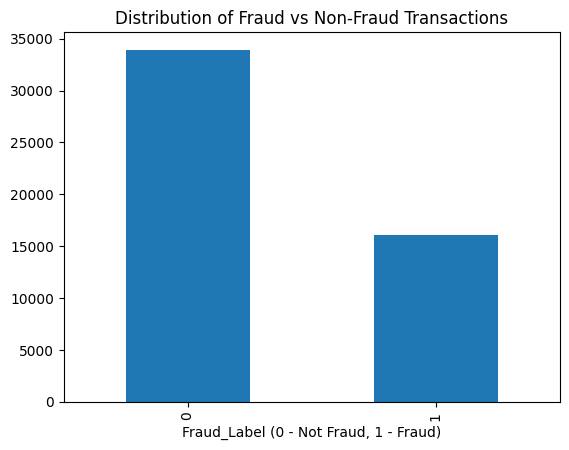

In [39]:
#visualization 1 - distribution of fraud vs non-fraud transactions - bar
 
target_counts.plot(kind='bar')
plt.title('Distribution of Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud_Label (0 - Not Fraud, 1 - Fraud)')
plt.show()

#more non fraud transactions than fraud transactions, indicating class imbalance in the dataset.

Merchant_Category
Restaurants    3255
Travel         3235
Groceries      3217
Clothing       3181
Electronics    3179
Name: count, dtype: int64


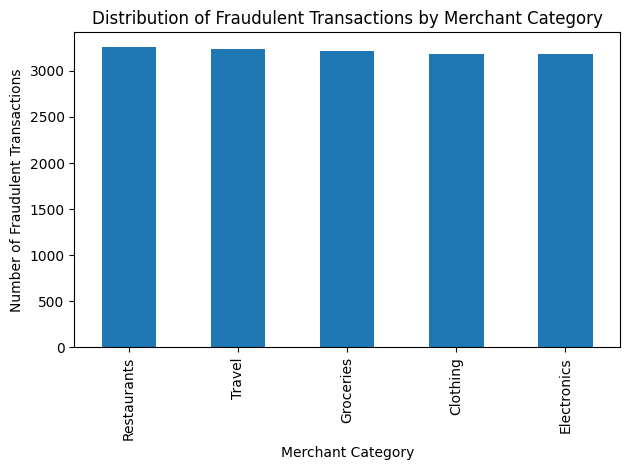

In [ ]:
#visualization 2 - merchant category fraudulent transaction distribution - bar

fraud_merchant_counts = df[df['Fraud_Label'] == 1]['Merchant_Category'].value_counts()
print(fraud_merchant_counts)

fraud_merchant_counts.plot(kind='bar')
plt.title('Distribution of Fraudulent Transactions by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Number of Fraudulent Transactions')

plt.tight_layout()
plt.show()

#resaurants experince the highest level of fraud

Location
Tokyo       3315
New York    3221
Sydney      3194
London      3181
Mumbai      3156
Name: count, dtype: int64


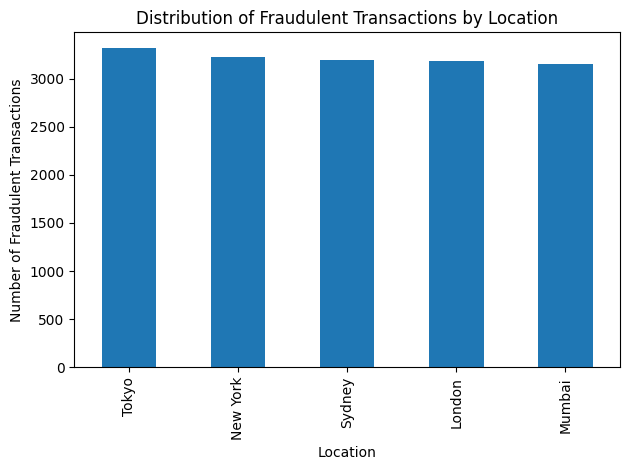

In [41]:
# visualization 3 - location distribution of fraudulent transactions - bar      

fraud_location_counts = df[df['Fraud_Label'] == 1]['Location'].value_counts()
print (fraud_location_counts) 

fraud_location_counts.plot(kind='bar')
plt.title('Distribution of Fraudulent Transactions by Location')
plt.xlabel('Location')
plt.ylabel('Number of Fraudulent Transactions')
plt.tight_layout()
plt.show()


### Section 2 Markdown

From my initial analysis of the data set, I found that it consists of 21 features and 50,000 observations. Overall, the dataset was very clean; there were no null values or duplicates present. I also found that there is a large class imbalance between the Fraud and Non-Fraud observations. Because of this, it will be imperative to ensure that the data is split with equal weight for the training and testing.


## 3. Feature Engineering


In [42]:
#engineered feature 1 - amount to balance ratio
# - identify overdrafts by negative values
# - identifies large transactions 


df['Amount_to_Balance_Ratio'] = df['Transaction_Amount'] / (df['Account_Balance'] + 1)



In [ ]:
#engineered feature 2 - ammount deiviation from 7 day average
# - identifies large transactions compared to recent history

df['Amount_Deviation_from_7d_Avg'] = df['Avg_Transaction_Amount_7d'] - df['Transaction_Amount']  

print(df.info())

#maybee add later
#df['frequency_failed'] = df['Failed_Transaction_Count_7d'] / (df['Daily_Transaction_Count'] + 1)
#df['older_card_flag'] = (df['Card_Age'] > ... ).astype(int)
#df['device_distance_age_risk'] = df['Transaction_Distance'] / (df['Card_Age'] + 1)
#df['older_card_tranaction_count]= df['older_card_flag'] * df['Daily_Transaction_Count']

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

### Section 3 Markdown


engineered feature 1 - amount to balance ratio:

Creates a ratio to compare the balance of the user's account to the amount of the transaction. I added this feature to identify relatively large transactions that may be a sign of fraud. 

engineered feature 2 - amount deviation from 7-day average:

The purpose of this feature is to flag transaction amounts that differ significantly from the recent ones. It does this by calculating the difference between the transaction amount and the average amount of transactions within a 7-day period.


## 4. Data Processing

[Train/test split, missing value handling, feature scaling]


In [44]:
# no null values  or duplicates where found. so there is no nneed to handle them

# train split 80-20
Y = df['Fraud_Label']
X = df.drop(columns=['Fraud_Label', 'Transaction_ID', 'User_ID','Risk_Score', 'Previous_Fraudulent_Activity','IP_Address_Flag', 'Timestamp'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)

# scalling and encoding for K means 

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Model 1: random forest without engineered features

[Implementation, training, evaluation]

In [45]:

x_1 = df.drop(columns=['Fraud_Label','Transaction_ID','User_ID','Timestamp','Amount_Deviation_from_7d_Avg','Amount_to_Balance_Ratio','Risk_Score','Previous_Fraudulent_Activity','IP_Address_Flag'])
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(x_1, Y, test_size=0.2, random_state=42,stratify=Y)

# Encoding categorical variables
X_train_1 = pd.get_dummies(X_train_1)
X_test_1 = pd.get_dummies(X_test_1)

# Align columns
X_train_1, X_test_1 = X_train_1.align(X_test_1, join='left', axis=1, fill_value=0)

# Scale data
scaler_1 = StandardScaler()
X_train_1_scaled = scaler_1.fit_transform(X_train_1)
X_test_1_scaled = scaler_1.transform(X_test_1)

#randoom forest model without engineered features
rf_model_1 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model_1.fit(X_train_1_scaled, y_train_1)


#predictions and statistics
y_pred_1 = rf_model_1.predict(X_test_1_scaled)

def rf_wo_ef():
    print('Accuracy:', accuracy_score(y_test_1, y_pred_1))
    print('Precision:', precision_score(y_test_1, y_pred_1))
    print('Recall:', recall_score(y_test_1, y_pred_1))
    print("F1 Score:", f1_score(y_test_1, y_pred_1))
rf_wo_ef()



Accuracy: 0.8772
Precision: 1.0
Recall: 0.617802676626206
F1 Score: 0.7637552904963447


In [46]:
#important features 
Feature_Importances_1 = pd.Series(rf_model_1.feature_importances_, index=X_train_1.columns).sort_values(ascending=False)

Feature_Importances_1.head(10)

Failed_Transaction_Count_7d    0.441543
Transaction_Distance           0.068170
Account_Balance                0.067838
Avg_Transaction_Amount_7d      0.067669
Transaction_Amount             0.067547
Card_Age                       0.064003
Daily_Transaction_Count        0.042010
Is_Weekend                     0.010046
Device_Type_Mobile             0.007591
Device_Type_Tablet             0.007572
dtype: float64

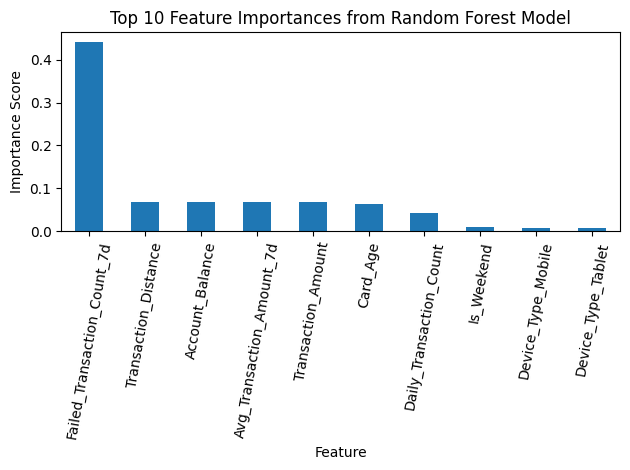

In [47]:
Feature_Importances_1.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances from Random Forest Model')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=80)


plt.tight_layout()
plt.show()   

## 5. Model 2: random forest with engineered features


In [48]:


rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# predictions
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

# evaluation
def rf_w_ef():
    print("Accuracy:", accuracy_score(y_test, rf_predictions))
    print("Precision:", precision_score(y_test, rf_predictions))
    print("Recall:", recall_score(y_test, rf_predictions))
    print("F1 Score:", f1_score(y_test, rf_predictions))
rf_w_ef()

Accuracy: 0.8772
Precision: 1.0
Recall: 0.617802676626206
F1 Score: 0.7637552904963447


In [ ]:
#Feture importance analysis

Feature_Importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

Feature_Importances.head(10)

Failed_Transaction_Count_7d     0.432134
Transaction_Distance            0.056033
Account_Balance                 0.054597
Avg_Transaction_Amount_7d       0.053576
Amount_Deviation_from_7d_Avg    0.053484
Transaction_Amount              0.053468
Amount_to_Balance_Ratio         0.053229
Card_Age                        0.052524
Daily_Transaction_Count         0.033894
Is_Weekend                      0.007933
dtype: float64

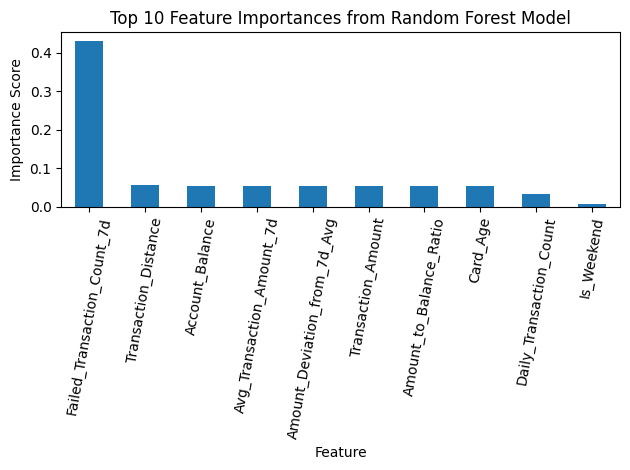

In [ ]:
#top ten feature importance visualization

Feature_Importances.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances from Random Forest Model')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=80)


plt.tight_layout()
plt.show()   

## 6. Model 3: kmeans 

['Failed_Transaction_Count_7d', 'Transaction_Distance', 'Account_Balance', 'Avg_Transaction_Amount_7d', 'Amount_Deviation_from_7d_Avg']
k=2: inertia=146888.90
k=3: inertia=129977.63
k=4: inertia=115277.88
k=5: inertia=105450.67
k=6: inertia=97435.67
k=7: inertia=89417.74
k=8: inertia=81629.77
k=9: inertia=77556.82
k=10: inertia=73949.59


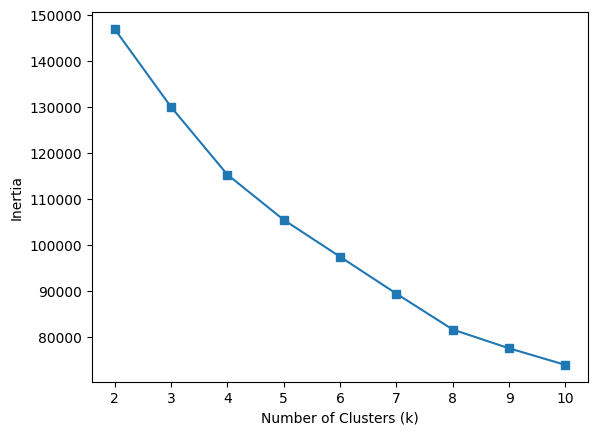

In [70]:
#finding optimal k

inertias = []
k_range = range(2, 11)

top_features = Feature_Importances.head(5).index.tolist()


print( top_features)

X_train_Top = X_train[top_features]
X_test_Top = X_test[top_features]

scaler = StandardScaler()
X_train_Top_scaled = scaler.fit_transform(X_train_Top)
X_test_Top_scaled = scaler.transform(X_test_Top)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X_train_Top_scaled)

    inertias.append(kmeans.inertia_)

    print(f"k={k}: inertia={kmeans.inertia_:.2f}")

plt.plot(k_range, inertias, marker='s')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [71]:
#k means clustering with k=5

kmeans = KMeans(n_clusters=5, random_state=42)
train_clusters = kmeans.fit_predict(X_train_Top_scaled)
test_clusters = kmeans.predict(X_test_Top_scaled)

#cluster analysis table
X_train_kmeans = pd.DataFrame(X_train_Top_scaled, columns=X_train_Top.columns)
X_train_kmeans['Cluster'] = train_clusters
X_train_kmeans['Fraud_Label'] = y_train.values

#statistcs summary 
print('training clusters summary:')
cluster_summary_train = X_train_kmeans.groupby('Cluster')['Fraud_Label'].agg(['count', 'mean'])
print(cluster_summary_train)

print('test clusters summary:')
cluster_summary_test = pd.DataFrame({'Cluster': test_clusters, 'Fraud_Label': y_test.values}).groupby('Cluster')['Fraud_Label'].agg(['count', 'mean'])
print(cluster_summary_test)

print('training and test cluster mean comparison:')
cluster_summary_combined = cluster_summary_train.merge(cluster_summary_test, on='Cluster', suffixes=('_train', '_test')).drop(columns=['count_test', 'count_train'])
cluster_summary_combined['mean_diff'] = cluster_summary_combined['mean_train'] - cluster_summary_combined['mean_test']
 
print(cluster_summary_combined)


#count - number of transactions in that cluster
#mean - fraud rate in that cluster

#similar results for training and testing - overfitting and underfitting are not a problem

training clusters summary:
         count      mean
Cluster                 
0         8951  0.278405
1         6867  0.151595
2         9067  0.340465
3         8298  0.296819
4         6817  0.553176
test clusters summary:
         count      mean
Cluster                 
0         2193  0.268582
1         1747  0.163709
2         2334  0.331620
3         1994  0.299398
4         1732  0.558314
training and test cluster mean comparison:
         mean_train  mean_test  mean_diff
Cluster                                  
0          0.278405   0.268582   0.009823
1          0.151595   0.163709  -0.012115
2          0.340465   0.331620   0.008846
3          0.296819   0.299398  -0.002580
4          0.553176   0.558314  -0.005138


In [72]:
cluster_profile = X_train_kmeans.groupby('Cluster').mean(numeric_only=True)
print(cluster_profile)

cluster_profile.head()

         Failed_Transaction_Count_7d  Transaction_Distance  Account_Balance  \
Cluster                                                                       
0                          -0.148890              0.913638        -0.085523   
1                          -0.946445             -0.198683         0.675028   
2                           0.133159             -0.908193        -0.013260   
3                           0.039357             -0.043909        -1.056483   
4                           0.923868              0.261894         0.735958   

         Avg_Transaction_Amount_7d  Amount_Deviation_from_7d_Avg  Fraud_Label  
Cluster                                                                        
0                         0.895156                      0.847046     0.278405  
1                        -0.736829                     -0.697327     0.151595  
2                         0.907238                      0.849707     0.340465  
3                        -0.791596            

,Failed_Transaction_Count_7d,Transaction_Distance,Account_Balance,Avg_Transaction_Amount_7d,Amount_Deviation_from_7d_Avg,Fraud_Label
Cluster,,,,,,
0,-0.148890,0.913638,-0.085523,0.895156,0.847046,0.278405
1,-0.946445,-0.198683,0.675028,-0.736829,-0.697327,0.151595
2,0.133159,-0.908193,-0.013260,0.907238,0.849707,0.340465
3,0.039357,-0.043909,-1.056483,-0.791596,-0.757792,0.296819
4,0.923868,0.261894,0.735958,-0.676251,-0.617502,0.553176


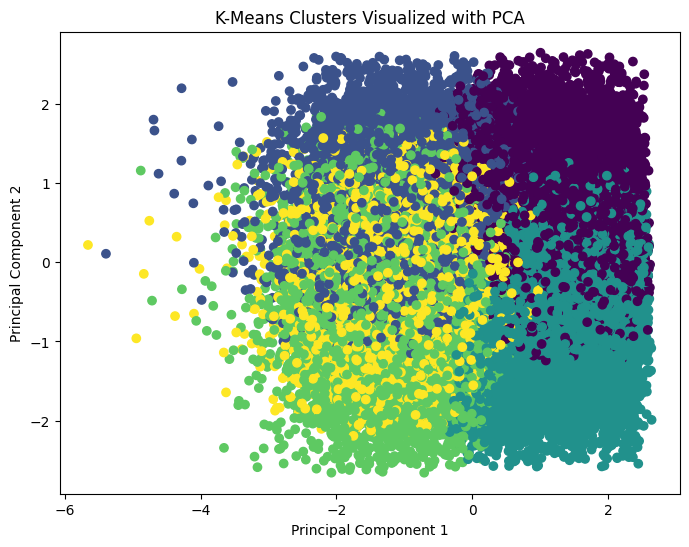

In [73]:
#kmeans vizualization using PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_Top_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()
    

## 7. Model Comparison

In [55]:

#random forest with out engineered features
print('Statiscics of Random Forest without Engineered Features:\n')
rf_wo_ef()

print('top 10 feature importances without engineered features:\n')

print(Feature_Importances_1.head(10))

time_wo_ef = 22.2
#random forest with engineered features
print('\nStatiscics of Random Forest with Engineered Features:\n')
rf_w_ef()

print('top 10 feature importances with engineered features:\n')
print(Feature_Importances.head(10))
time_w_ef =25.2

print('\n k-means clustering mean analysis:\n')
print(cluster_summary_combined)




Statiscics of Random Forest without Engineered Features:

Accuracy: 0.8772
Precision: 1.0
Recall: 0.617802676626206
F1 Score: 0.7637552904963447
top 10 feature importances without engineered features:

Failed_Transaction_Count_7d    0.441543
Transaction_Distance           0.068170
Account_Balance                0.067838
Avg_Transaction_Amount_7d      0.067669
Transaction_Amount             0.067547
Card_Age                       0.064003
Daily_Transaction_Count        0.042010
Is_Weekend                     0.010046
Device_Type_Mobile             0.007591
Device_Type_Tablet             0.007572
dtype: float64

Statiscics of Random Forest with Engineered Features:

Accuracy: 0.8772
Precision: 1.0
Recall: 0.617802676626206
F1 Score: 0.7637552904963447
top 10 feature importances with engineered features:

Failed_Transaction_Count_7d     0.432134
Transaction_Distance            0.056033
Account_Balance                 0.054597
Avg_Transaction_Amount_7d       0.053576
Amount_Deviation_from_

In [66]:
comparison_table = pd.DataFrame({
    'Model': ['Random Forest without Engineered Features', 'Random Forest with Engineered Features'],
    'Accuracy': [accuracy_score(y_test_1, y_pred_1), accuracy_score(y_test, rf_predictions)],
    'Precision': [precision_score(y_test_1, y_pred_1), precision_score(y_test, rf_predictions)],
    'Recall': [recall_score(y_test_1, y_pred_1), recall_score(y_test, rf_predictions)],
    'F1 Score': [f1_score(y_test_1, y_pred_1), f1_score(y_test, rf_predictions)],
    'Time (seconds)': [time_wo_ef, time_w_ef] })
comparison_table.head()

,Model,Accuracy,Precision,Recall,F1 Score,Time (seconds)
0,Random Forest without Engineered Features,0.8772,1.0,0.617803,0.763755,22.2
1,Random Forest with Engineered Features,0.8772,1.0,0.617803,0.763755,25.2


In [57]:
cluster_profile = X_train_kmeans.groupby('Cluster').mean(numeric_only=True)
cluster_profile.head()

,Failed_Transaction_Count_7d,Transaction_Distance,Account_Balance,Avg_Transaction_Amount_7d,Amount_Deviation_from_7d_Avg,Fraud_Label
Cluster,,,,,,
0,-0.148890,0.913638,-0.085523,0.895156,0.847046,0.278405
1,-0.946445,-0.198683,0.675028,-0.736829,-0.697327,0.151595
2,0.133159,-0.908193,-0.013260,0.907238,0.849707,0.340465
3,0.039357,-0.043909,-1.056483,-0.791596,-0.757792,0.296819
4,0.923868,0.261894,0.735958,-0.676251,-0.617502,0.553176


In this assignment, I created three different models: a random forest model that does not use any engineered features, one that does use engineered features, and a K-means clustering model that uses the top features from the random forest model that uses engineered features to help identify the transactions that need extra monitoring. The two random forest models had the same accuracy, precision, recall, and f-1 scores, but the model that used engineered features took three more seconds to run than the one that did not. On top of that, the engineered features that were added changed the results of the top features list. I plan to use the engineered feature model along with the K-means model for the final project.


## 8. Next Steps & Reflection

For the final version of this project, the additional engineered features I plan to add include a feature that combines the IP address flag and the transaction distance to bring more attention to transactions that occur far from the user's usual location and are also performed on an unusual device. Another feature I plan to add is one that measures risk by combining the age of the card with the transaction distance. The final feature I plan to add will flag older cards.

To further improve my model, I plan to add the new engineered features and adjust the hyperparameters to ensure that the model runs in its most optimized state..
